# **Electron exibing Brownian Motion**

In this code we simulate ...

**Credits**
* Juan Andrés Guarín Rojas ([GitHub](https://github.com/AndresGuarin))


This notebook follows the next order
* [1. Computational scheme](#sec_1)

# **Import libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ECond.simulation.solver as solver
import ECond.simulation.animation as ani

from datetime import datetime
from matplotlib import cm
from matplotlib.colors import Normalize

## **Some ideas**

* Only calculate forces for the moving particles (electrons)

## **1. Computational scheme** <a class="anchor" id="sec_1"></a>

We'll use the Langevin equation to model the Brownian motion
$$m \frac{d\vec{v}_i}{dt} = -m\gamma \vec{v}_i+\vec{R}+\vec{K}_i$$

The field force is given by the Coulombs' forces between the electrons, the lorentz force due to an external electromagnetic field, and the confinement potential
$$ \vec{K}_i = q_i\left(\vec{E} + \vec{v}_i\times\vec{B} \right) - q_i \vec{\nabla} \phi +  \sum\limits_{j=1}^{N}\frac{1}{4\pi\epsilon_0}\frac{q_i q_j}{r_{ij}^3}\vec{r}_{ij}\,,$$

For implementing this equations into the code we define the next dimensionless quantities:
$$\bar{t}=\sqrt{\frac{e^2}{4\pi\epsilon_0 m_e\sigma^3}}t\,, \,\,\,\,\,\,  \vec{r}' = \frac{\vec{r}}{\sigma}\,, \,\,\,\,\,\ \vec{v}' = \frac{d\vec{r}'}{d\bar{t}}\,, \,\,\,\,\,\ \bar{r}_{ij} =\frac{r_{ij}}{\sigma}\,, \,\,\,\,\,\ \bar{q}_i = \frac{q_i}{e}$$
where $\sigma=361.5\times 10^{-12}[\text{m}]$ is the lattice constant cristal structure of copper, $e$ is the elemental charge and $m_e$ is the electron rest mass. We also define the next dimensionless fields

$$\vec{E}' = \frac{4\pi\epsilon_0 \sigma^2}{e}\vec{E}\,, \,\,\,\,\,\, \vec{B}' = \sqrt{\frac{4\pi\epsilon_0\sigma^3}{m_e}} \vec{B}\,, \,\,\,\,\,\, \phi' = \frac{4\pi\epsilon_0 \sigma^3}{e} \phi$$

With this definitions the Newton's Law of motion for the electrons is left as

$$ \frac{d\vec{v}'_{i}}{d \bar{t}}= -\bar{\gamma}\vec{v}'_i + \vec{R}'+ \bar{q}_i \left(\vec{E}'+\vec{v}'_i\times\vec{B}' \right) -\bar{q}_i\frac{\partial \phi'}{\partial \vec{r}'}+\sum\limits_{j=1}^{N} \frac{\bar{q}_i \bar{q}_j}{\bar{r}_{ij}^2}\hat{r}'_{ij} \,. $$

## **2. Test**

In [ ]:
def plot_intial_state(X0,Y0,Vx0,Vy0):
    plt.figure(figsize=(4,4))
    plt.plot(X0,Y0,'or')
    plt.quiver(X0, Y0, Vx0, Vy0, scale_units='xy',angles='xy',scale=3,color='orange',width=0.01)

    bb = np.max([np.abs(X0),np.abs(Y0)])*1.4
    plt.xlim(-bb,bb)
    plt.ylim(-bb,bb)
    plt.show()

def get_conners(box):
      a,b,c,d = box
      X = np.array([a,b,b,a,a])
      Y = np.array([c,c,d,d,c])
      return X,Y

def plot_boxes(box1,box2):
    X1, Y1 = get_conners(box1) 
    X2, Y2 = get_conners(box2); 
    plt.plot(X1,Y1,'-b',lw=1.7)
    plt.plot(X2,Y2,'-b',lw=1.7)

def get_uniques(X,Y):
    Z=X+Y*1j
    W=np.unique(Z)
    return np.real(W), np.imag(W)

def get_positions_wire(box1,box2,seed=None):
    a,b,c,d = box1
    l,m,n,p = box2

    if seed!=None: np.random.seed(5656)
    Np=220; mx=50; my=5; Lx=(b-a)+(d-l)+(p-a)+(m-l); Ly=(l-c)
    X0 = np.random.randint(low=0, high=mx,size=Np)*(Lx/mx)+a
    Y0 = np.random.randint(low=0, high=my,size=Np)*(Ly/my)+c
    X0, Y0 = get_uniques(X0,Y0)

    b0=b
    b1=b+(d-l)
    b2=b+(d-l)+(p-a)

    X1, Y1 = X0[X0<=b0],Y0[X0<=b0]
    X2, Y2 = X0[(X0>b0)*(X0<=b1)],Y0[(X0>b0)*(X0<=b1)]
    X3, Y3 = X0[(X0>b1)*(X0<=b2)],Y0[(X0>b1)*(X0<=b2)]
    X4, Y4 = X0[X0>b2],Y0[X0>b2]

    delta1=b-l
    delta2=b+(d-l)+(p-a)-p
    delta3=d-l
    delta4=c-a
    delta5=l-b-(d-l)-(p-a)

    X0f = np.concatenate([X1,Y2+delta1,X3-delta2,Y4+delta4])
    Y0f = np.concatenate([Y1,X2-delta1,Y3+delta3,X4+delta5])
    return X0f, Y0f

### **Initial conditions**

In [3]:
# Square 
X0 = np.array([-1.5,-1.5, 1.5, 1.5, 1.5])
Y0 = np.array([ 0.5, 2.0, 0.5,-2.0, 2.0])
Vx0 = np.array([1, 0, -1, -1, 2])
Vy0 = np.array([ 1,-1, 0,1, 0])

# 1 particle
X0, Y0, Vx0, Vy0 = np.array([0.2]),np.array([0.2]),np.array([1]),np.array([1.2])

# Random particles
np.random.seed(5656)
Np=20; m=15; L=2.6; LV=1.5
X0 = np.random.randint(low=-m, high=m,size=Np)*(L/m)
Y0 = np.random.randint(low=-m, high=m,size=Np)*(L/m)
Vx0 = X0 = (np.random.random(Np)-0.5)*LV
Vy0 = X0 = (np.random.random(Np)-0.5)*LV

### **Potential well and electric field**

In [4]:
# preliminar
depth = 1
slope = 3
width = 3
def func(x,slope=slope,width=width):
    return np.tanh(slope*(x-width)) + np.tanh(slope*(-x-width))
def diff_func(x,slope=slope,width=width):
    return slope/np.cosh(slope*(x-width))**2 - slope/np.cosh(slope*(x+width))**2

# Cuadrado
def potential_Well(x,y,slope=slope,width=width,depth=depth):
    return func(x,slope,width)*func(y,slope,width)*depth
def E0(X,Y,t):
     Ex = -depth*func(Y)*diff_func(X)
     Ey = -depth*func(X)*diff_func(Y)
     return [Ex, Ey] #In order: [Ex, Ey]

# Circuito cerrado cuadrado
def potential_Well1(x,y):
    return potential_Well(x+9,y-9,width=12)-potential_Well(x+9,y-9,width=6)    
def E1(X,Y,t):
     Ex = -depth*func(Y-9,width=12)*diff_func(X+9,width=12) + depth*func(Y-9,width=6)*diff_func(X+9,width=6)
     Ey = -depth*func(X+9,width=12)*diff_func(Y-9,width=12) + -depth*func(X+9,width=6)*diff_func(Y-9,width=6)
     return [Ex, Ey] #In order: [Ex, Ey]

### **Simulación**

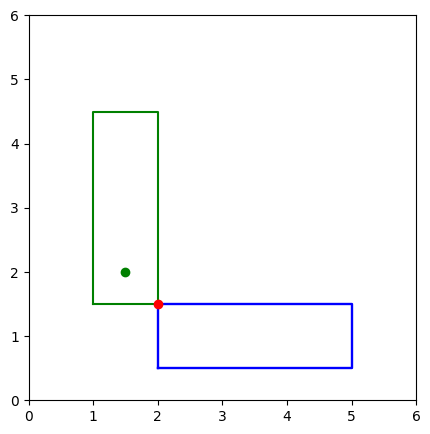

In [57]:
%matplotlib inline
a=2; b=5; c=0.5; d=1.5; delta=a-d
X1, Y1 = get_conners([a,b,c,d])
plt.figure(figsize=(5,5))
plt.plot(X1,Y1,'-b',lw=1.7)
plt.plot(Y1+delta,X1-delta,'-g')
plt.plot(a,d,'or')
plt.plot(d,a,'og')
plt.xlim(0,6)
plt.ylim(0,6)
plt.show()

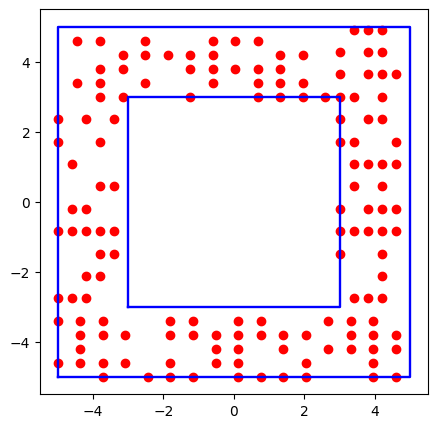

In [ ]:
box1=[-5,5,-5,5]
box2=[-3,3,-3,3]

plt.figure(figsize=(5,5))
X0, Y0 = get_positions_wire(box1,box2,18383)
plt.plot(X0,Y0,'or')
plot_boxes(box1,box2)
plt.show()

In [ ]:
# Choose parameters 
h = 0.01; N = 2000

# Set intial conditions
# electrons


Np = len(X0)

# potential well
depth = 1.5
slope = 3
width = 4
def func(x,slope=slope,width=width):
    return np.tanh(slope*(x-width)) + np.tanh(slope*(-x-width))

def diff_func(x,slope=slope,width=width):
    return slope/np.cosh(slope*(x-width))**2 - slope/np.cosh(slope*(x+width))**2

def potential_Well(x,y,slope=slope,width=width,depth=depth):
    return func(x,slope,width)*func(y,slope,width)*depth

def potential_Well1(x,y):
    return potential_Well(x,y,slope,5*width) - potential_Well(x,y,slope,3*width)

Q=-1

# Set external fields
def B0(X,Y,t):
    return X*0 #In order: [Bz]

def E1(X,Y,t):
     Ex = -depth*func(Y,width=5*width)*diff_func(X,width=5*width) + depth*func(Y,width=3*width)*diff_func(X,width=3*width)
     Ey = -depth*func(X,width=5*width)*diff_func(Y,width=5*width) + depth*func(X,width=3*width)*diff_func(Y,width=3*width)
     return [Ex, Ey] #In order: [Ex, Ey]

# Other physical parameters
gamma = 0.5
R = 10 #Con R=4 y un sólo el electrón, el movimiento no cesa 

sim = solver.ECond(h,N,Np,E1,B0,gamma,R)
s = sim.simulate([X0,Y0,Vx0,Vy0])

self1 = sim.get_self()

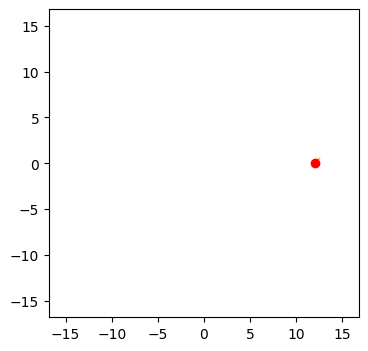

In [18]:
%matplotlib inline
plot_intial_state(X0,Y0,Vx0,Vy0)

In [36]:
%matplotlib auto
%matplotlib auto

plt.figure(figsize=(5,5))
for i in range(Np):
    X = s[0][:,i]
    Y = s[1][:,i]
    plt.plot(X,Y,'-r',lw=1,alpha=0.5)
    plt.plot(X[0],Y[0],'or',ms=4)
#D=5
#plt.xlim(-D,D)
#plt.ylim(-D,D)

a=np.arctanh(0.9)/slope + 5*width
b=np.arctanh(0.9)/slope + 3*width
plot_boxes([-a,a,-a,a],[-b,b,-b,b])
plt.show()

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg


In [34]:
%matplotlib auto
%matplotlib auto

ani.animate_path(self1,s,save=False,verbose=True,j0=1,dj=4,interval=0,
                 plot_params=['-r','or',1, 6, 0.5], length=8,L=8,box1=[-a,a,-a,a],box2=[-b,b,-b,b])
#plt.show()

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg


In [9]:
Vx = s[2][:,0]
Vy = s[3][:,0]
V = np.sqrt(Vx**2+Vy**2)
tt = np.arange(len(Vx))*h

%matplotlib auto
plt.figure(figsize=(7,5))
plt.plot(tt,V,'-b',lw=1.5)
plt.hlines(0,tt[0],tt[-1],'black','--',lw=1,alpha=0.5)
plt.xlabel(r'$\bar{t}$')
plt.ylabel(r'$\overline{v}$')
plt.show()

Using matplotlib backend: QtAgg
